# Notebook 3 - reports, benchmark signals, and review gates

This walkthrough mirrors `examples/05_programmatic_report.py` and `examples/06_benchmark.py`. It treats conversion reports as CI-ready data, demonstrates warning-code gates, and validates a small synthetic benchmark.


In [1]:
import importlib.util
import json
import tempfile
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

from sql2sqlx import ConversionOptions, convert_directory

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists()
)
EXAMPLES = ROOT / "examples"
HELPER = EXAMPLES / "_notebook_benchmark_helper.py"
spec = importlib.util.spec_from_file_location("notebook_benchmark_helper", HELPER)
assert spec is not None and spec.loader is not None
bench = importlib.util.module_from_spec(spec)
spec.loader.exec_module(bench)

## Treat warning codes as review gates

The report is structured data, so migrations can fail CI on selected warning codes while allowing intentionally reviewed warnings to pass.


In [2]:
result = convert_directory(str(EXAMPLES / "sql"))
warning_counts = Counter(warning.code for warning in result.report.warnings)
blocking_codes = {"FALLBACK_OPERATIONS", "DUPLICATE_TARGET", "SELF_REFERENCE"}
blockers = [warning for warning in result.report.warnings if warning.code in blocking_codes]
{
    "warning_counts": dict(warning_counts),
    "blocking_findings": [(warning.path, warning.line, warning.code) for warning in blockers],
    "failures": len(result.report.failures),
}

{'warning_counts': {'ORDER_ASSUMED': 3,
  'SCRIPT_FILE': 1,
  'SCRIPT_WRITES': 1,
  'CREATE_NO_AS': 1},
 'blocking_findings': [],
 'failures': 0}

## Inspect JSON report fields

`to_dict()` is the same representation written by the CLI `--report` flag. It includes action counts, warning details, failures, dependency rewrites, and timing data.


In [3]:
report_dict = result.report.to_dict()
print(json.dumps(report_dict, indent=2)[:2000])
assert report_dict["statements"] >= len(result.files)
assert report_dict["actions_by_type"]
assert report_dict["failures"] == {}

{
  "files_read": 8,
  "statements": 11,
  "actions_by_type": {
    "operations": 6,
    "view": 1,
    "table": 2
  },
  "refs_rewritten": 7,
  "refs_unresolved": [],
  "warnings": [
    {
      "code": "ORDER_ASSUMED",
      "message": "Table marts.order_facts is written by statements in multiple files (maintenance/backfill_script.sql, marts/order_facts.sql); their relative execution order was inferred from sorted file paths - verify the generated dependency chain.",
      "path": "maintenance/backfill_script.sql",
      "line": 0
    },
    {
      "code": "ORDER_ASSUMED",
      "message": "Table staging.orders is written by statements in multiple files (maintenance/cleanup.sql, staging/stg_orders.sql); their relative execution order was inferred from sorted file paths - verify the generated dependency chain.",
      "path": "maintenance/cleanup.sql",
      "line": 0
    },
    {
      "code": "ORDER_ASSUMED",
      "message": "Table staging.customers is written by statements in mul

## Visualize warning counts

A warning chart is a compact review artifact for pull requests. A value of zero is still meaningful: it shows that the checked sample corpus had no warnings.


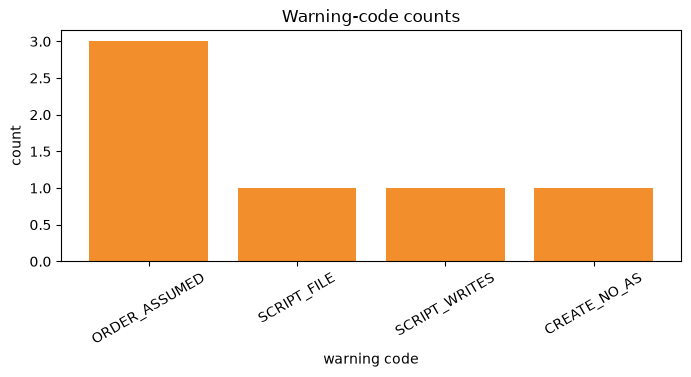

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
labels = list(warning_counts) or ["none"]
values = [warning_counts[label] for label in labels] if warning_counts else [0]
ax.bar(labels, values, color="#F28E2B")
ax.set_title("Warning-code counts")
ax.set_ylabel("count")
ax.set_xlabel("warning code")
ax.tick_params(axis="x", rotation=30)
plt.show()

## Run a small synthetic benchmark

This benchmark intentionally stays small enough for documentation builds. It uses the same generator pattern as the standalone benchmark example: multiple files, chained CTAS statements, metadata clauses, and append statements.


In [5]:
with tempfile.TemporaryDirectory(prefix="sql2sqlx_nb_bench_") as tmp:
    corpus = Path(tmp)
    lines = bench.generate(corpus, files=3, statements=8)
    size = sum(path.stat().st_size for path in corpus.rglob("*.sql"))
    start = time.perf_counter()
    bench_result = convert_directory(str(corpus), options=ConversionOptions(jobs=0))
    seconds = time.perf_counter() - start

benchmark = {
    "files": 3,
    "statements_per_file": 8,
    "lines": lines,
    "size_bytes": size,
    "actions": sum(bench_result.report.actions_by_type.values()),
    "seconds": round(seconds, 4),
    "lines_per_second": round(lines / seconds, 1),
    "failures": len(bench_result.report.failures),
}
benchmark

{'files': 3,
 'statements_per_file': 8,
 'lines': 279,
 'size_bytes': 8181,
 'actions': 30,
 'seconds': 0.2158,
 'lines_per_second': 1293.1,
 'failures': 0}

## Validate benchmark outputs

The generated corpus has one base table plus one append operation and eight CTAS statements per file, so the action count is deterministic: `files * (statements_per_file + 2)`.


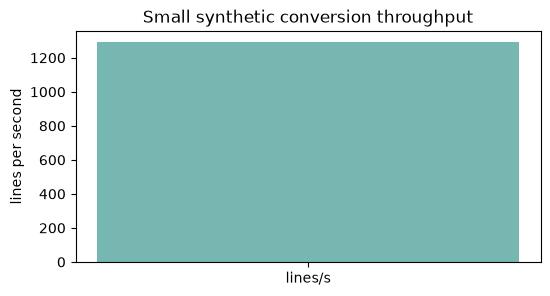

{'files': 3,
 'statements_per_file': 8,
 'lines': 279,
 'size_bytes': 8181,
 'actions': 30,
 'seconds': 0.2158,
 'lines_per_second': 1293.1,
 'failures': 0}

In [6]:
expected_actions = benchmark["files"] * (benchmark["statements_per_file"] + 2)
assert benchmark["actions"] == expected_actions
assert benchmark["failures"] == 0
assert benchmark["lines_per_second"] > 0

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(["lines/s"], [benchmark["lines_per_second"]], color="#76B7B2")
ax.set_title("Small synthetic conversion throughput")
ax.set_ylabel("lines per second")
plt.show()
benchmark